In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
backend=AerSimulator()
# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])

m = np.array([[1, 0, 0, 0],
                 [0, 2, -1, 0],
                 [0, -1, 2, -1],
                 [0, 0, -1, 2]])
b = np.array([0,np.sqrt(2)/2,0.5,0.5])
nb_qubits = 2

In [3]:
d,u = np.linalg.eig(m)
d

array([3.41421356, 2.        , 0.58578644, 1.        ])

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([0.        +1.52655666e-16j, 0.70710678-3.33066907e-16j,
       0.5       +2.77555756e-17j, 0.5       +2.77555756e-17j])

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(k,l):
        return np.kron(k,l)
    M1 = (np.dot(np.dot(Ub,tensor(z,I)),np.conj(Ub.T))
        + np.dot(np.dot(Ub,tensor(I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([ 7.81178959e+00-1.25327338e-30j,  6.55662219e-01-6.56273592e-34j,
        2.09320836e+00+3.18682166e-31j, -8.70748375e-18-5.12138303e-32j])

In [7]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 

 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)



C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
    

In [8]:

def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc

depth=2
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)

# Parameters = np.array([random.random() for _ in range(0, nb_params)])
Parameters = np.array([0.52822308, 0.40519007, 0.48765494, 0.56605484, 0.25056377,
       0.60720049, 0.53942809, 0.61184558, 0.99554639, 0.74489715,
       0.81785207, 0.25282619, 0.41243963, 0.11381233, 0.76354501,
       0.12637757, 0.54608607, 0.65329402, 0.20654193, 0.89865501,
       0.5440122 , 0.26823429, 0.24008469, 0.44891939, 0.56125941,
       0.05261654, 0.02638421, 0.06759133, 0.32614957, 0.39266204,
       0.19674497, 0.49752617, 0.77267437, 0.36766943, 0.13459572,
       0.3618098 ])




In [9]:

def circ(parameters):
    x=QuantumRegister(6)
    c=ClassicalRegister(4)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[4:6])
    circuit.h(x[0:4])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[4],x[5]])    
    circuit.append(C_u2gate, [x[1],x[4],x[5]])    
    circuit.append(C_u3gate, [x[2],x[4],x[5]])    
    circuit.append(C_u4gate, [x[3],x[4],x[5]])    

#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits=4, approximation_degree=0, do_swaps=True, 
                   inverse=True, insert_barriers=False, name='qft')
    circuit.measure(x[0:4],c)       
    return circuit

In [10]:
# circ(parameters).draw("mpl") 

In [11]:
shots = 100000
def cost(parameters):
    job = backend.run(pm.run(circ(parameters)),shots = shots).result()
    result = job.get_counts(0)
    res = 1 - result['0000']/shots
    return res
# cost(parameters)


In [12]:
import warnings
warnings.filterwarnings("ignore")
from qiskit_algorithms.optimizers import SPSA
def save(nfev, parameters, cost, learning_rate, trust_region):
    
    global Cost,Params
    Cost.append(cost)
    Params.append(parameters)
    print(nfev, cost)
Cost = []
Params = []
spsa = SPSA(maxiter=1000, callback =save)
spsa.minimize(cost, parameters)
print(Cost)

3 0.54615
6 0.57858
9 0.53101
12 0.58468
15 0.5595399999999999
18 0.54537
21 0.45130000000000003
24 0.49238000000000004
27 0.29544000000000004
30 0.31318
33 0.31362
36 0.30596
39 0.26961
42 0.26673
45 0.27036000000000004
48 0.26907000000000003
51 0.24514999999999998
54 0.24826000000000004
57 0.23036999999999996
60 0.22974000000000006
63 0.20292
66 0.19752999999999998
69 0.19525000000000003
72 0.19404
75 0.18547999999999998
78 0.16303999999999996
81 0.16363000000000005
84 0.12909000000000004
87 0.12397999999999998
90 0.12329000000000001
93 0.11417999999999995
96 0.11389000000000005
99 0.11412
102 0.11295999999999995
105 0.09367000000000003
108 0.07674999999999998
111 0.08016000000000001
114 0.03200000000000003
117 0.031059999999999977
120 0.024349999999999983
123 0.023419999999999996
126 0.02070000000000005
129 0.020299999999999985
132 0.015660000000000007
135 0.011709999999999998
138 0.010990000000000055
141 0.010759999999999992
144 0.007780000000000009
147 0.007120000000000015
150 0.0

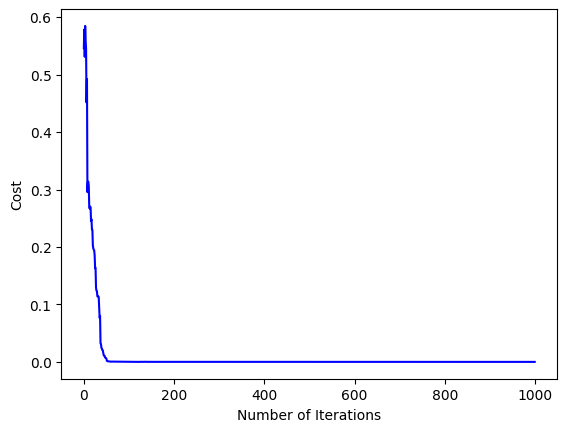

In [13]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [14]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [15]:
e = []
F =[ ]
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(b - Psi/norm)
    f = abs(np.dot(Psi,b))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

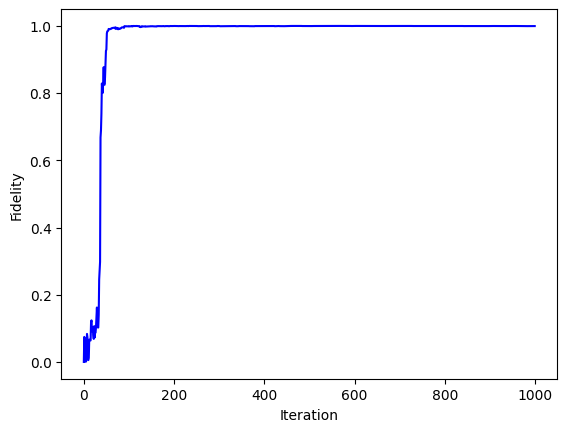

In [16]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [17]:
min(norm_e)*100

0.8695699118426958

Text(0.5, 0, 'Iteration')

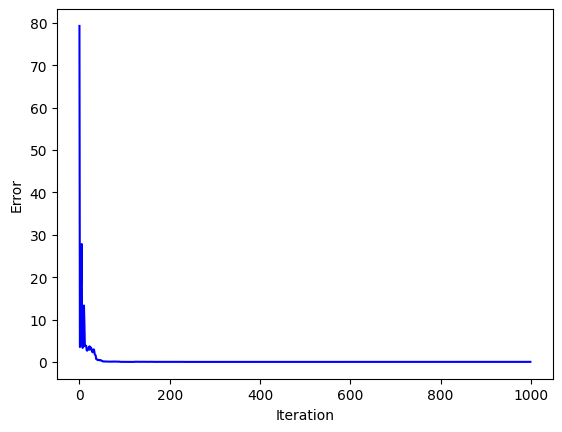

In [18]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [19]:
norm_e[np.argmax(F)]

0.008695699118426959

In [20]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [21]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.00057993, 0.00596686, 0.00301139, 0.00553236])

In [23]:
print(F)

[0.00015906267569864985, 0.07459912484318554, 0.06952776784200791, 0.0014948804501978819, 0.002794193701968361, 0.001289535018982468, 0.034821975208997775, 0.08349484388903691, 0.07366238504135471, 0.007077373089796844, 0.005614968315223375, 0.012050597903278127, 0.06660956014690358, 0.06508007823847274, 0.06501840606904526, 0.06407011383573512, 0.1169334469324145, 0.12380569300253307, 0.09144534022305588, 0.10111543375421453, 0.10382578021853771, 0.08102896429441277, 0.06872884345883644, 0.10660937838785337, 0.07271525136760955, 0.08769276936806532, 0.08764331529358874, 0.10447815616316812, 0.13690658108562234, 0.16208388951018826, 0.11919742117891773, 0.1026160629980648, 0.10247604145898996, 0.13982194151650382, 0.24575714336950066, 0.27112663036019014, 0.2979430474948828, 0.6679425263604252, 0.6888635905671259, 0.7392218595417567, 0.8285914099117947, 0.8092871963661775, 0.8008466525417826, 0.8433705902254317, 0.8771932315767353, 0.8259100204413276, 0.8248510269362413, 0.846741639255